# `f0` vs `f0_raw_smoothing` vs `f0_smoothing_chandelier_exit` — performance comparison

Three tables generated by the same vectorbt backtest loop; signal and exit
definitions differ:

- `f0`: DEMA-style cross of two EMAs (`n1` fast vs `n2` slow), fixed
  `rr_ratio` take-profit.
- `f0_raw_smoothing`: single EMA (`n1`) plus a second EMA applied to the first
  (`smooth_period`); long/short is `smoothed > ema1` (and vice versa); fixed
  `rr_ratio` take-profit.
- `f0_smoothing_chandelier_exit`: same smoothing entry, but exits via a
  Chandelier trailing stop (`trail_mult * ATR`) instead of an `rr_ratio` TP.

This notebook aggregates each row in the three tables, ranks the smoothing
variant against the baseline, and isolates the effect of swapping the
take-profit exit for a Chandelier trail on the smoothing signal.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
from pathlib import Path

candidates = [
    Path.cwd() / 'backtest_results.db',
    Path.cwd().parent / 'backtest_results.db',
    Path.cwd().parent.parent / 'src' / 'backtest_results.db',
    Path('/home/chris/backtester/dema_strat/src/backtest_results.db'),
]
DB_PATH = next((p for p in candidates if p.exists()), None)
assert DB_PATH is not None, f'backtest_results.db not found in {candidates}'
print('using', DB_PATH)

con = sqlite3.connect(DB_PATH)
f0 = pd.read_sql('SELECT * FROM f0', con)
smooth = pd.read_sql('SELECT * FROM f0_raw_smoothing', con)
chandelier = pd.read_sql('SELECT * FROM f0_smoothing_chandelier_exit', con)
con.close()

print('f0 rows:', len(f0))
print('f0_raw_smoothing rows:', len(smooth))
print('f0_smoothing_chandelier_exit rows:', len(chandelier))

using /home/chris/backtester/dema_strat/src/backtest_results.db
f0 rows: 8100
f0_raw_smoothing rows: 6750
f0_smoothing_chandelier_exit rows: 4050


In [2]:
metric_cols = ['expectancy', 'win_rate', 'max_dd', 'sharpe_ratio',
               'profit_factor', 'num_trades', 'return_pct']

def summary(df):
    return df[metric_cols].describe().T[['mean','std','min','50%','max']].round(4)

print('--- f0 summary ---')
print(summary(f0))
print()
print('--- f0_raw_smoothing summary ---')
print(summary(smooth))
print()
print('--- f0_smoothing_chandelier_exit summary ---')
print(summary(chandelier))

--- f0 summary ---
                     mean          std        min         50%          max
expectancy        -0.0296       0.0017    -0.0329     -0.0298      -0.0207
win_rate          38.6019      12.3162    14.4588     35.5944      68.2823
max_dd             5.8711       7.5910     0.2910      2.2981      39.1535
sharpe_ratio     -40.0314      53.2064  -277.3967    -16.2420      -1.4230
profit_factor      0.5879       0.2087     0.1053      0.6343       0.8957
num_trades     96273.2399  124167.3502  5346.0000  39408.5000  641549.0000
return_pct        -5.8642       7.5955   -39.1535     -2.2948      -0.2229

--- f0_raw_smoothing summary ---
                     mean          std        min         50%          max
expectancy        -0.0275       0.0028    -0.0326     -0.0285      -0.0130
win_rate          45.2537      12.9495    15.0365     44.7327      68.3139
max_dd             5.1443       7.1723     0.1407      2.0118      36.5387
sharpe_ratio     -37.9510      50.9310  -267.35

In [3]:
key_cols = ['n1', 'atr_period', 'sl_mult', 'rr_ratio', 'use_vwap',
            'asset', 'timeframe']

f0_grouped = f0.groupby(key_cols, as_index=False)[metric_cols].mean()
smooth_grouped = smooth.groupby(key_cols, as_index=False)[metric_cols].mean()

merged = f0_grouped.merge(
    smooth_grouped, on=key_cols, suffixes=('_f0', '_smooth'))
print('aligned configs:', len(merged))

aligned configs: 1350


In [4]:
rows = []
for metric in metric_cols:
    a, b = f'{metric}_f0', f'{metric}_smooth'
    if metric == 'max_dd':
        wins = int((merged[b].abs() < merged[a].abs()).sum())
    else:
        wins = int((merged[b] > merged[a]).sum())
    delta_mean = (merged[b] - merged[a]).mean()
    delta_median = (merged[b] - merged[a]).median()
    rows.append({'metric': metric, 'smoothing_wins': wins,
                 'total': len(merged),
                 'mean_delta': round(delta_mean, 4),
                 'median_delta': round(delta_median, 4)})
print(pd.DataFrame(rows))


          metric  smoothing_wins  total  mean_delta  median_delta
0     expectancy            1186   1350      0.0021        0.0018
1       win_rate            1118   1350      6.6518        2.4545
2         max_dd             833   1350     -0.7268       -0.3297
3   sharpe_ratio             816   1350      2.0804        1.4141
4  profit_factor             372   1350     -0.0190       -0.0182
5     num_trades             536   1350  -6977.7363    -3300.3500
6     return_pct             833   1350      0.7242        0.3302


In [5]:
merged['expectancy_diff'] = merged['expectancy_smooth'] - merged['expectancy_f0']
merged['sharpe_diff']     = merged['sharpe_ratio_smooth'] - merged['sharpe_ratio_f0']
merged['return_diff']     = merged['return_pct_smooth'] - merged['return_pct_f0']
merged['maxdd_improve']   = merged['max_dd_f0'].abs() - merged['max_dd_smooth'].abs()
merged['pf_diff']         = merged['profit_factor_smooth'] - merged['profit_factor_f0']

print(merged[['expectancy_diff','sharpe_diff','return_diff','maxdd_improve','pf_diff']]
      .describe().T.round(4))


                  count    mean      std      min     25%     50%     75%  \
expectancy_diff  1350.0  0.0021   0.0022  -0.0057  0.0008  0.0018  0.0033   
sharpe_diff      1350.0  2.0804  11.1180 -38.7939 -1.9330  1.4141  6.2016   
return_diff      1350.0  0.7242   2.2195  -5.3454 -0.2464  0.3302  1.3407   
maxdd_improve    1350.0  0.7268   2.2183  -5.3450 -0.2395  0.3297  1.3424   
pf_diff          1350.0 -0.0190   0.0409  -0.1306 -0.0432 -0.0182  0.0033   

                     max  
expectancy_diff   0.0111  
sharpe_diff      48.3162  
return_diff      10.9169  
maxdd_improve    10.9169  
pf_diff           0.1087  


In [6]:
score = (merged['expectancy_diff'].rank(pct=True) +
         merged['sharpe_diff'].rank(pct=True) +
         merged['return_diff'].rank(pct=True) +
         merged['maxdd_improve'].rank(pct=True) +
         merged['pf_diff'].rank(pct=True)) / 5
merged['composite_score'] = score.round(4)

ranking = merged.sort_values('composite_score', ascending=False)
top = ranking[['timeframe','use_vwap','n1','atr_period','sl_mult','rr_ratio',
              'expectancy_f0','expectancy_smooth',
              'sharpe_ratio_f0','sharpe_ratio_smooth',
              'return_pct_f0','return_pct_smooth',
              'max_dd_f0','max_dd_smooth','composite_score']].head(15).round(4)
print('top 15 configs where smoothing variant beats DEMA cross:')
print(top)


top 15 configs where smoothing variant beats DEMA cross:
    timeframe  use_vwap  n1  atr_period  sl_mult  rr_ratio  expectancy_f0  \
255        M1         1   5          21      3.0       1.0        -0.0319   
165        M1         1   5          18      3.0       1.0        -0.0317   
261        M1         1   5          21      3.0       1.5        -0.0323   
75         M1         1   5          14      3.0       1.0        -0.0316   
81         M1         1   5          14      3.0       1.5        -0.0324   
267        M1         1   5          21      3.0       2.0        -0.0326   
87         M1         1   5          14      3.0       2.0        -0.0327   
171        M1         1   5          18      3.0       1.5        -0.0322   
177        M1         1   5          18      3.0       2.0        -0.0325   
525        M1         1   7          21      3.0       1.0        -0.0317   
69         M1         1   5          14      3.0       0.5        -0.0311   
249        M1      

In [7]:
by_tf = merged.groupby('timeframe').agg(
    f0_expectancy=('expectancy_f0','mean'),
    smooth_expectancy=('expectancy_smooth','mean'),
    f0_sharpe=('sharpe_ratio_f0','mean'),
    smooth_sharpe=('sharpe_ratio_smooth','mean'),
    f0_return=('return_pct_f0','mean'),
    smooth_return=('return_pct_smooth','mean'),
    f0_maxdd=('max_dd_f0', lambda s: s.abs().mean()),
    smooth_maxdd=('max_dd_smooth', lambda s: s.abs().mean()),
    wins_expectancy=('expectancy_diff', lambda s: int((s>0).sum())),
    n=('expectancy_diff','size'),
).round(4)
print(by_tf)


           f0_expectancy  smooth_expectancy  f0_sharpe  smooth_sharpe  \
timeframe                                                               
M1               -0.0310            -0.0286   -94.8436       -90.6811   
M15              -0.0281            -0.0263    -6.1812        -5.6536   
M5               -0.0296            -0.0276   -19.0694       -17.5183   

           f0_return  smooth_return  f0_maxdd  smooth_maxdd  wins_expectancy  \
timeframe                                                                      
M1          -13.9786       -12.4280   13.9789       12.4283              450   
M15          -0.8882        -0.7265    0.9045        0.7362              289   
M5           -2.7256        -2.2654    2.7300        2.2685              447   

             n  
timeframe       
M1         450  
M15        450  
M5         450  


In [8]:
print(smooth.groupby('smooth_period')[metric_cols].mean().round(4))


               expectancy  win_rate  max_dd  sharpe_ratio  profit_factor  \
smooth_period                                                              
6                 -0.0273   45.1410  5.5337      -40.3950         0.5606   
8                 -0.0273   45.2442  5.2716      -38.7203         0.5669   
10                -0.0274   45.2946  5.0915      -37.5991         0.5708   
12                -0.0276   45.3064  4.9619      -36.8145         0.5727   
14                -0.0279   45.2824  4.8628      -36.2261         0.5734   

               num_trades  return_pct  
smooth_period                          
6              96362.6163     -5.5292  
8              91676.4822     -5.2675  
10             88432.3185     -5.0872  
12             85982.4807     -4.9576  
14             84023.6200     -4.8583  


In [9]:
n = len(merged)
print(f'Configs where smoothing beats DEMA cross on expectancy: '
      f'{(merged["expectancy_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing beats DEMA cross on Sharpe:     '
      f'{(merged["sharpe_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing has shallower drawdown:         '
      f'{(merged["maxdd_improve"] > 0).sum()}/{n}')
print(f'Configs where smoothing has higher return %:            '
      f'{(merged["return_diff"] > 0).sum()}/{n}')
print(f'Configs where smoothing has higher profit factor:       '
      f'{(merged["pf_diff"] > 0).sum()}/{n}')

Configs where smoothing beats DEMA cross on expectancy: 1186/1350
Configs where smoothing beats DEMA cross on Sharpe:     816/1350
Configs where smoothing has shallower drawdown:         833/1350
Configs where smoothing has higher return %:            833/1350
Configs where smoothing has higher profit factor:       372/1350


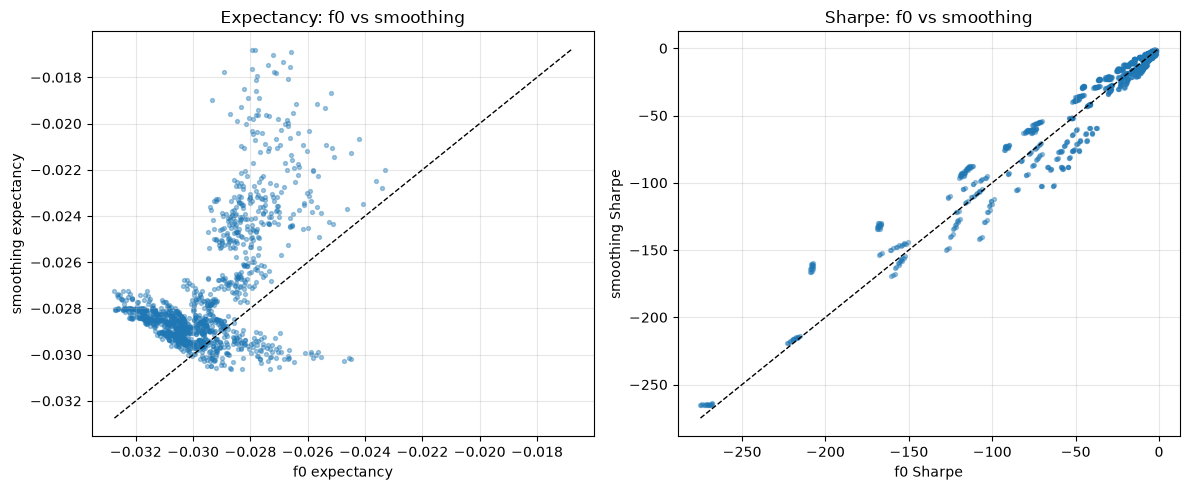

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(merged['expectancy_f0'], merged['expectancy_smooth'],
                s=8, alpha=0.4)
lims = [min(merged['expectancy_f0'].min(), merged['expectancy_smooth'].min()),
        max(merged['expectancy_f0'].max(), merged['expectancy_smooth'].max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('f0 expectancy')
axes[0].set_ylabel('smoothing expectancy')
axes[0].set_title('Expectancy: f0 vs smoothing')
axes[0].grid(alpha=0.3)

axes[1].scatter(merged['sharpe_ratio_f0'], merged['sharpe_ratio_smooth'],
                s=8, alpha=0.4)
lims = [min(merged['sharpe_ratio_f0'].min(), merged['sharpe_ratio_smooth'].min()),
        max(merged['sharpe_ratio_f0'].max(), merged['sharpe_ratio_smooth'].max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('f0 Sharpe')
axes[1].set_ylabel('smoothing Sharpe')
axes[1].set_title('Sharpe: f0 vs smoothing')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## `f0_smoothing_chandelier_exit` vs `f0_raw_smoothing`

Same smoothing entry signal; only the exit mechanism differs. To make the
two tables directly comparable, group on every column they share
(`n1`, `atr_period`, `sl_mult`, `use_vwap`, `smooth_period`, `asset`,
`timeframe`) and average over the exit-side knobs that the other table
does not carry (`rr_ratio` for `f0_raw_smoothing`, `trail_mult` for
`f0_smoothing_chandelier_exit`).

In [11]:
cs_key_cols = ['n1', 'atr_period', 'sl_mult', 'use_vwap',
               'smooth_period', 'asset', 'timeframe']

smooth_c   = smooth.groupby(cs_key_cols, as_index=False)[metric_cols].mean()
chand_c    = chandelier.groupby(cs_key_cols, as_index=False)[metric_cols].mean()

cs_merged = smooth_c.merge(
    chand_c, on=cs_key_cols, suffixes=('_smooth', '_chandelier'))
print('aligned configs (smoothing vs chandelier):', len(cs_merged))

aligned configs (smoothing vs chandelier): 1350


In [12]:
rows = []
for metric in metric_cols:
    a, b = f'{metric}_smooth', f'{metric}_chandelier'
    if metric == 'max_dd':
        wins = int((cs_merged[b].abs() < cs_merged[a].abs()).sum())
    else:
        wins = int((cs_merged[b] > cs_merged[a]).sum())
    delta_mean   = (cs_merged[b] - cs_merged[a]).mean()
    delta_median = (cs_merged[b] - cs_merged[a]).median()
    rows.append({'metric': metric,
                 'chandelier_wins': wins,
                 'total': len(cs_merged),
                 'mean_delta': round(delta_mean, 4),
                 'median_delta': round(delta_median, 4)})
print(pd.DataFrame(rows))

          metric  chandelier_wins  total  mean_delta  median_delta
0     expectancy              457   1350     -0.0003       -0.0002
1       win_rate              230   1350     -6.0543       -4.9621
2         max_dd             1028   1350     -1.1777       -0.2409
3   sharpe_ratio             1103   1350     11.4135        2.1589
4  profit_factor              975   1350      0.0353        0.0332
5     num_trades              300   1350 -20507.0631    -4434.0000
6     return_pct             1033   1350      1.1789        0.2415


In [13]:
cs_merged['expectancy_diff'] = cs_merged['expectancy_chandelier'] - cs_merged['expectancy_smooth']
cs_merged['sharpe_diff']     = cs_merged['sharpe_ratio_chandelier'] - cs_merged['sharpe_ratio_smooth']
cs_merged['return_diff']     = cs_merged['return_pct_chandelier'] - cs_merged['return_pct_smooth']
cs_merged['maxdd_improve']   = cs_merged['max_dd_smooth'].abs() - cs_merged['max_dd_chandelier'].abs()
cs_merged['pf_diff']         = cs_merged['profit_factor_chandelier'] - cs_merged['profit_factor_smooth']
cs_merged['wr_diff']         = cs_merged['win_rate_chandelier'] - cs_merged['win_rate_smooth']

print(cs_merged[['expectancy_diff','sharpe_diff','return_diff',
                 'maxdd_improve','pf_diff','wr_diff']]
      .describe().T.round(4))

                  count     mean      std      min      25%     50%      75%  \
expectancy_diff  1350.0  -0.0003   0.0010  -0.0057  -0.0009 -0.0002   0.0001   
sharpe_diff      1350.0  11.4135  19.9083  -1.5676   0.4903  2.1589  12.0419   
return_diff      1350.0   1.1789   2.1832  -0.3002   0.0156  0.2415   1.2370   
maxdd_improve    1350.0   1.1777   2.1837  -0.2994   0.0144  0.2409   1.2367   
pf_diff          1350.0   0.0353   0.0603  -0.0822  -0.0073  0.0332   0.0667   
wr_diff          1350.0  -6.0543   6.7725 -17.0847 -12.3481 -4.9621  -0.8537   

                     max  
expectancy_diff   0.0044  
sharpe_diff      86.2518  
return_diff      11.2890  
maxdd_improve    11.2890  
pf_diff           0.1785  
wr_diff           6.5433  


In [14]:
score_cs = (cs_merged['expectancy_diff'].rank(pct=True) +
            cs_merged['sharpe_diff'].rank(pct=True) +
            cs_merged['return_diff'].rank(pct=True) +
            cs_merged['maxdd_improve'].rank(pct=True) +
            cs_merged['pf_diff'].rank(pct=True)) / 5
cs_merged['composite_score'] = score_cs.round(4)

ranking_cs = cs_merged.sort_values('composite_score', ascending=False)
top_cs = ranking_cs[['timeframe','use_vwap','n1','atr_period','sl_mult',
                    'smooth_period',
                    'expectancy_smooth','expectancy_chandelier',
                    'sharpe_ratio_smooth','sharpe_ratio_chandelier',
                    'return_pct_smooth','return_pct_chandelier',
                    'max_dd_smooth','max_dd_chandelier',
                    'composite_score']].head(15).round(4)
print('top 15 configs where chandelier exit beats rr_ratio TP:')
print(top_cs)

top 15 configs where chandelier exit beats rr_ratio TP:
     timeframe  use_vwap  n1  atr_period  sl_mult  smooth_period  \
999         M1         0  11          21      1.0             12   
1266        M1         0  13          21      1.0             10   
1269        M1         0  13          21      1.0             12   
909         M1         0  11          18      1.0             12   
1272        M1         0  13          21      1.0             14   
819         M1         0  11          14      1.0             12   
1176        M1         0  13          18      1.0             10   
1002        M1         0  11          21      1.0             14   
1086        M1         0  13          14      1.0             10   
732         M1         0   9          21      1.0             14   
552         M1         0   9          14      1.0             14   
1092        M1         0  13          14      1.0             14   
1089        M1         0  13          14      1.0           

In [15]:
by_tf_cs = cs_merged.groupby('timeframe').agg(
    smooth_expectancy=('expectancy_smooth','mean'),
    chand_expectancy=('expectancy_chandelier','mean'),
    smooth_sharpe=('sharpe_ratio_smooth','mean'),
    chand_sharpe=('sharpe_ratio_chandelier','mean'),
    smooth_return=('return_pct_smooth','mean'),
    chand_return=('return_pct_chandelier','mean'),
    smooth_maxdd=('max_dd_smooth', lambda s: s.abs().mean()),
    chand_maxdd=('max_dd_chandelier', lambda s: s.abs().mean()),
    smooth_pf=('profit_factor_smooth','mean'),
    chand_pf=('profit_factor_chandelier','mean'),
    wins_expectancy=('expectancy_diff', lambda s: int((s>0).sum())),
    n=('expectancy_diff','size'),
).round(4)
print(by_tf_cs)

           smooth_expectancy  chand_expectancy  smooth_sharpe  chand_sharpe  \
timeframe                                                                     
M1                   -0.0286           -0.0291       -90.6811      -61.6423   
M15                  -0.0263           -0.0263        -5.6536       -4.6610   
M5                   -0.0276           -0.0281       -17.5183      -13.3090   

           smooth_return  chand_return  smooth_maxdd  chand_maxdd  smooth_pf  \
timeframe                                                                      
M1              -12.4280       -9.3934       12.4283       9.3937     0.3316   
M15              -0.7265       -0.6275        0.7362       0.6395     0.7636   
M5               -2.2654       -1.8622        2.2685       1.8666     0.6115   

           chand_pf  wins_expectancy    n  
timeframe                                  
M1           0.3965              216  450  
M15          0.7742              189  450  
M5           0.6420        

In [16]:
print('Configs where chandelier beats rr_ratio TP on expectancy:',
      f'{(cs_merged["expectancy_diff"] > 0).sum()}/{len(cs_merged)}')
print('Configs where chandelier beats rr_ratio TP on Sharpe:    ',
      f'{(cs_merged["sharpe_diff"] > 0).sum()}/{len(cs_merged)}')
print('Configs where chandelier has shallower drawdown:        ',
      f'{(cs_merged["maxdd_improve"] > 0).sum()}/{len(cs_merged)}')
print('Configs where chandelier has higher return %:           ',
      f'{(cs_merged["return_diff"] > 0).sum()}/{len(cs_merged)}')
print('Configs where chandelier has higher profit factor:      ',
      f'{(cs_merged["pf_diff"] > 0).sum()}/{len(cs_merged)}')
print('Configs where chandelier has higher win rate:           ',
      f'{(cs_merged["wr_diff"] > 0).sum()}/{len(cs_merged)}')

Configs where chandelier beats rr_ratio TP on expectancy: 457/1350
Configs where chandelier beats rr_ratio TP on Sharpe:     1103/1350
Configs where chandelier has shallower drawdown:         1028/1350
Configs where chandelier has higher return %:            1033/1350
Configs where chandelier has higher profit factor:       975/1350
Configs where chandelier has higher win rate:            230/1350


In [17]:
print('--- chandelier exit: by trail_mult ---')
print(chandelier.groupby('trail_mult')[metric_cols].mean().round(4))
print()
print('--- smoothing rr_ratio TP: by rr_ratio ---')
print(smooth.groupby('rr_ratio')[metric_cols].mean().round(4))

--- chandelier exit: by trail_mult ---
            expectancy  win_rate  max_dd  sharpe_ratio  profit_factor  \
trail_mult                                                              
1.0            -0.0286   40.5778  4.2049      -29.3901         0.5593   
2.0            -0.0281   39.5295  4.0208      -26.6992         0.6072   
3.0            -0.0268   37.4911  3.6741      -23.5230         0.6462   

            num_trades  return_pct  
trail_mult                          
1.0         72912.8030     -4.2007  
2.0         69562.4874     -4.0159  
3.0         63890.0311     -3.6665  

--- smoothing rr_ratio TP: by rr_ratio ---
          expectancy  win_rate  max_dd  sharpe_ratio  profit_factor  \
rr_ratio                                                              
0.25         -0.0282   47.6829  7.1164      -56.9568         0.4446   
0.50         -0.0278   49.0675  5.8004      -44.2305         0.5273   
1.00         -0.0273   45.8078  4.6622      -33.2492         0.5998   
1.50       

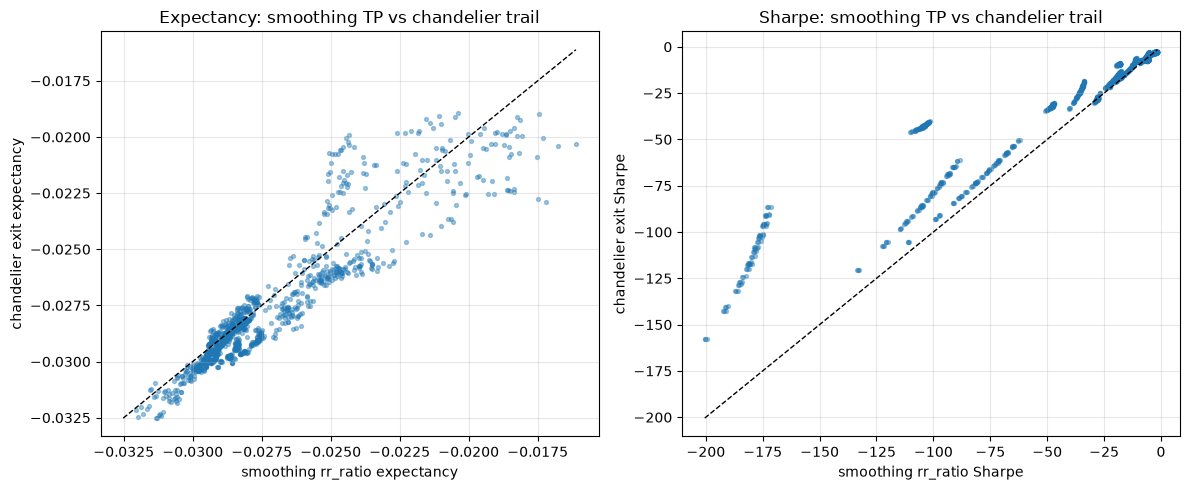

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(cs_merged['expectancy_smooth'], cs_merged['expectancy_chandelier'],
                s=8, alpha=0.4)
lims = [min(cs_merged['expectancy_smooth'].min(), cs_merged['expectancy_chandelier'].min()),
        max(cs_merged['expectancy_smooth'].max(), cs_merged['expectancy_chandelier'].max())]
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlabel('smoothing rr_ratio expectancy')
axes[0].set_ylabel('chandelier exit expectancy')
axes[0].set_title('Expectancy: smoothing TP vs chandelier trail')
axes[0].grid(alpha=0.3)

axes[1].scatter(cs_merged['sharpe_ratio_smooth'], cs_merged['sharpe_ratio_chandelier'],
                s=8, alpha=0.4)
lims = [min(cs_merged['sharpe_ratio_smooth'].min(), cs_merged['sharpe_ratio_chandelier'].min()),
        max(cs_merged['sharpe_ratio_smooth'].max(), cs_merged['sharpe_ratio_chandelier'].max())]
axes[1].plot(lims, lims, 'k--', lw=1)
axes[1].set_xlabel('smoothing rr_ratio Sharpe')
axes[1].set_ylabel('chandelier exit Sharpe')
axes[1].set_title('Sharpe: smoothing TP vs chandelier trail')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()